In [1]:
# Dependencias. En Colab, descomenta. En local, usa requirements.txt:
#     pip install -r requirements.txt
#     python -m spacy download en_core_web_sm
#
# !pip install -q spacy nltk datasets wordcloud langdetect
# !python -m spacy download en_core_web_sm

In [2]:
# (incluido en la celda anterior)

In [3]:
# Importación de librerías
import pandas as pd
import string
import re
import nltk
import spacy
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

for recurso in ['punkt_tab', 'stopwords', 'wordnet']:
    nltk.download(recurso, quiet=True)   # quiet: no imprime rutas locales
print("Recursos de NLTK listos")

Recursos de NLTK listos


In [4]:
nlp = spacy.load("en_core_web_sm")

In [5]:
import pyarrow as pa
import pyarrow.compute as pc
from datasets import load_dataset

# El dataset son 1,12 GB en un unico JSONL con 847.209 peliculas, cada una con
# hasta 10 reseñas. `datasets` lo guarda en Arrow mapeado a disco.
dataset = load_dataset("pkchwy/letterboxd-all-movie-data", split="train")
print(f"Peliculas en el dataset completo: {len(dataset):,}")

# OJO CON LO QUE SIGNIFICA ESTE FILTRO: 'year' es el año de ESTRENO DE LA
# PELICULA, no la fecha en que se escribio la reseña. "2024" quiere decir
# "reseñas de peliculas estrenadas en 2024", escritas en cualquier momento.
#
# Se filtra sobre la tabla Arrow y no con dataset.filter(lambda ...): el
# lambda deserializa cada una de las 847.209 filas con su lista de reseñas
# dentro y tarda unos 18 minutos; el filtro vectorizado de pyarrow trabaja
# sobre la columna mapeada a disco y tarda menos de dos segundos.
tabla = dataset.data.table
tabla_2024 = tabla.filter(pc.equal(tabla.column('year'), pa.scalar('2024')))
print(f"Peliculas estrenadas en 2024: {tabla_2024.num_rows:,}")

# A pandas solo lo que se usa
df = tabla_2024.select(['title', 'year', 'rating', 'reviews']).to_pandas()
df = df[df['reviews'].apply(lambda r: r is not None and len(r) > 0)]
reviews_df = df.explode('reviews').reset_index(drop=True)

# Cada reseña es {username, review_text, likes}.
# NO se extrae 'username': son personas reales y esto va a un repositorio
# publico. Solo interesan el texto y los likes.
reviews_df['review_text'] = reviews_df['reviews'].apply(
    lambda d: d.get('review_text', '') if isinstance(d, dict) else ''
)
reviews_df['likes'] = reviews_df['reviews'].apply(
    lambda d: int(d.get('likes', 0) or 0) if isinstance(d, dict) else 0
)
reviews_df = reviews_df.drop(columns=['reviews'])
reviews_df['review_text'] = reviews_df['review_text'].astype(str)
reviews_df = reviews_df[reviews_df['review_text'].str.strip() != '']

# 'rating' es la nota MEDIA de la pelicula, no la de cada reseña.
# Hay peliculas de 2024 sin nota (llegan como None): con .astype(float) el
# notebook original reventaba aqui. pd.to_numeric(errors='coerce') las deja
# como NaN, que es lo que son: una nota que no existe, no un cero.
reviews_df['average_rating'] = pd.to_numeric(
    reviews_df['rating'].astype(str).str.replace(' out of 5', '', regex=False),
    errors='coerce'
)
sin_nota = reviews_df['average_rating'].isna().sum()
print(f"Reseñas de peliculas sin nota media: {sin_nota:,} "
      f"({sin_nota/len(reviews_df)*100:.1f}%) -> se quedan como NaN")
reviews_df = reviews_df[['title', 'year', 'average_rating', 'review_text', 'likes']]
print(f"Reseñas de peliculas de 2024: {len(reviews_df):,}")
reviews_df.head()

Peliculas en el dataset completo: 847,209


Peliculas estrenadas en 2024: 40,486


Reseñas de peliculas sin nota media: 80,565 (67.6%) -> se quedan como NaN
Reseñas de peliculas de 2024: 119,096


,title,year,average_rating,review_text,likes
0,Samuel,2024,4.63,“En fait j’aime pas grandir par ce que depuis ...,1454
1,Samuel,2024,4.63,bérénice tu es la plus cool on aurait été trop...,843
2,Samuel,2024,4.63,pleurer rire pleurer pleurer rire,737
3,Samuel,2024,4.63,phrases que j’aime ça fait 10 min que je pleure :,579
4,Samuel,2024,4.63,le boug fait une crise de la dizaine,531


> ### Una diferencia que no sabemos explicar
>
> El trabajo entregado en su día decía **38.531 reseñas** de películas de 2024, que quedaban en 36.321 tras limpiar. Ejecutando hoy el mismo filtro sobre el mismo dataset salen **119.096**, y 111.798 tras deduplicar: tres veces más.
>
> Lo único que hemos podido descartar es que sea un artefacto del `groupby` con el que se agrupan las reseñas por película. **No sabemos a qué se debe la diferencia.** Las explicaciones posibles —que el dataset de Hugging Face se haya actualizado desde entonces, o que la ejecución original se hiciera sobre una descarga parcial— no las podemos comprobar, porque el dataset no está versionado.
>
> Lo dejamos escrito en vez de arreglar el número hacia atrás: una cifra que no cuadra y no se sabe por qué es un resultado, no un error que tapar.

## **Películas ordenadas por número de reviews**

In [6]:
# Peliculas de 2024 ordenadas por numero de reseñas
movies_df = (reviews_df.groupby(['title', 'year']).size()
             .reset_index(name='num_reviews').sort_values('num_reviews', ascending=False))
print(f"{len(movies_df):,} peliculas de 2024 con reseñas")
print(movies_df.head(20).to_string(index=False))

19,648 peliculas de 2024 con reseñas
             title year  num_reviews
           Reversi 2024           40
        Carnalismo 2024           40
Grand Theft Hamlet 2024           36
       Inheritance 2024           36
              Real 2024           36
Removal of the Eye 2024           30
            Escape 2024           30
        To(get)her 2024           30
 Dragon Ball DAIMA 2024           29
            Heresy 2024           28
        Sugar Baby 2024           28
     Second Chance 2024           27
              Rust 2024           27
         Freelance 2024           27
7 Beats Per Minute 2024           27
              Rita 2024           27
  A Son & a Father 2024           27
          Brothers 2024           26
            Winner 2024           24
 Busy P Says "Oui" 2024           24


## **Películas y reviews agrupadas por año**

In [7]:
# Reparto de reseñas por pelicula: ¿estan concentradas en unos pocos titulos?
print(reviews_df.groupby('title').size().describe().round(1).to_string())
print(f"\nLas 10 peliculas mas reseñadas acumulan el "
      f"{movies_df.head(10)['num_reviews'].sum() / len(reviews_df) * 100:.1f}% de las reseñas")

count    19648.0
mean         6.1
std          4.0
min          1.0
25%          2.0
50%          6.0
75%          9.0
max         40.0

Las 10 peliculas mas reseñadas acumulan el 0.3% de las reseñas


In [8]:
# Guardar el corpus de 2024 COMPLETO (antes de deduplicar y de muestrear).
# Es el punto de partida: quien quiera trabajar con todo, parte de aqui.
reviews_df.to_parquet('letterboxd_reviews_filtered.parquet', index=False)
print(f"letterboxd_reviews_filtered.parquet -> {reviews_df.shape[0]:,} reseñas, "
      f"{reviews_df['title'].nunique():,} peliculas (corpus 2024 completo)")

letterboxd_reviews_filtered.parquet -> 119,096 reseñas, 19,648 peliculas (corpus 2024 completo)


Guardamos en Parquet en lugar de CSV porque es mucho más eficiente en tamaño y velocidad de lectura. En sesiones posteriores basta con `pd.read_parquet('letterboxd_reviews_filtered.parquet')`, sin volver a descargar 1,12 GB de HuggingFace.

**Qué significa exactamente este filtro.** La columna `year` del dataset es el **año de estreno de la película**, no la fecha en que se escribió la reseña. Así que el corpus es *«reseñas de películas estrenadas en 2024»*, escritas en cualquier momento. No es un corte temporal de las reseñas, y conviene no confundirlo.

**Los `.parquet` no se suben al repositorio.** Son intermedios que este notebook regenera, y el corpus son reseñas de usuarios reales redistribuidas vía HuggingFace: se enlaza la fuente y no se republica el contenido.

## Text Pre-processing

The objective of text preprocessing is to clean and transform raw text data into a structured and standardized format that is suitable for analysis. This process typically includes steps such as removing noise (e.g., special characters, numbers), converting text to lowercase for consistency, eliminating stop words (common but uninformative words), and applying techniques like lemmatization to reduce words to their base forms

In [9]:
# Deduplicar por texto: hay reseñas identicas repetidas entre peliculas
antes = len(reviews_df)
reviews_df = reviews_df.drop_duplicates(subset=['review_text']).reset_index(drop=True)
print(f"Deduplicado por texto: {antes:,} -> {len(reviews_df):,} reseñas")

# ---------------------------------------------------------------------------
# MUESTRA, Y POR QUE.
# El corpus completo de 2024 son ~112.000 reseñas. Procesarlas enteras en un
# portatil sin GPU pasa de una hora solo en lematizacion, POS tagging y
# deteccion de idioma. Este notebook trabaja sobre una muestra aleatoria con
# semilla fija para que se pueda ejecutar de principio a fin en unos minutos.
#
# Para procesar el corpus entero, pon N_MUESTRA = None. En Colab con mas RAM
# y tiempo, es perfectamente viable.
#
# La muestra es aleatoria simple sobre el corpus ya deduplicado: no se elige
# por popularidad ni por idioma, asi que conserva el reparto real de ambos.
# ---------------------------------------------------------------------------
N_MUESTRA = 12000

if N_MUESTRA is not None and N_MUESTRA < len(reviews_df):
    reviews_df = reviews_df.sample(n=N_MUESTRA, random_state=42).reset_index(drop=True)
    print(f"MUESTRA de {len(reviews_df):,} reseñas (semilla 42) sobre el corpus completo")
else:
    print(f"Corpus completo: {len(reviews_df):,} reseñas")

# Identificador unico por reseña: es lo que despues permite volver a unir el
# POS tagging con su reseña sin depender del texto.
reviews_df['review_id'] = reviews_df.index

def normalize_text(text):
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    combined_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # Emoticonos
        u"\U0001F300-\U0001F5FF"  # Simbolos y pictogramas
        u"\U0001F680-\U0001F6FF"  # Transporte y mapas
        u"\U0001F1E0-\U0001F1FF"  # Banderas
        u"\u4e00-\u9fff"          # Chino
        u"\u3040-\u30ff"          # Hiragana y katakana
        u"\uac00-\ud7af"          # Hangul
        u"\U00002702-\U000027B0"  # Dingbats
        u"\u200d"                 # Zero Width Joiner
        "]+", flags=re.UNICODE)

    text = combined_pattern.sub(r'', text)
    return text.lower().strip()

reviews_df['normalized_review'] = reviews_df['review_text'].apply(normalize_text)
reviews_df = reviews_df[reviews_df['normalized_review'] != ""].reset_index(drop=True)
print(f"Con texto tras normalizar: {len(reviews_df):,}")
reviews_df.sort_values(by='likes', ascending=False).head()

Deduplicado por texto: 119,096 -> 111,798 reseñas
MUESTRA de 12,000 reseñas (semilla 42) sobre el corpus completo


Con texto tras normalizar: 11,993


,title,year,average_rating,review_text,likes,review_id,normalized_review
8045,Longlegs,2024,3.33,Calling yourself longlegs as a serial killer i...,58328,8050,calling yourself longlegs as a serial killer i...
3698,Conclave,2024,3.91,divas in long dresses gossiping with each othe...,48163,3700,divas in long dresses gossiping with each othe...
9438,Dune: Part Two,2024,4.39,Need a friend like Stilgar to hype me up all t...,34614,9444,need a friend like stilgar to hype me up all t...
1495,Nosferatu,2024,3.71,The dangers of a little crush,34190,1497,the dangers of a little crush
6443,Dune: Part Two,2024,4.39,one of those moviegoing experiences i’ll cheri...,29716,6446,one of those moviegoing experiences i’ll cheri...


In [10]:
# Tokenization
def tokenize_text(text):
    tokens = word_tokenize(text, language='english', preserve_line=True)
    return tokens

reviews_df['tokenized_review'] = reviews_df['normalized_review'].apply(tokenize_text)
reviews_df.head()

,title,year,average_rating,review_text,likes,review_id,normalized_review,tokenized_review
0,Adios Amigo,2024,NaN,¡QUE PUTA BELLEZA!Definitivamente gracias a es...,8,0,¡que puta bellezadefinitivamente gracias a est...,"[¡que, puta, bellezadefinitivamente, gracias, ..."
1,"I Am the River, the River Is Me",2024,3.53,Cried way too much over the humble beauty of i...,4,1,cried way too much over the humble beauty of i...,"[cried, way, too, much, over, the, humble, bea..."
2,Choir,2024,NaN,idk if i cried bc of this or my period either ...,1,2,idk if i cried bc of this or my period either ...,"[idk, if, i, cried, bc, of, this, or, my, peri..."
3,Paria,2024,NaN,Op z’n Nederlands weer slecht geacteerd en gep...,3,3,op z’n nederlands weer slecht geacteerd en gep...,"[op, z, ’, n, nederlands, weer, slecht, geacte..."
4,Agatha All Along,2024,3.85,"""i loved being a witch"" made me cry my eyes out",2737,4,i loved being a witch made me cry my eyes out,"[i, loved, being, a, witch, made, me, cry, my,..."


In [11]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))



# High-frequency industry terms
industry_terms = ['film', 'movie', 'show', 'watch', 'see', 'cinema', 'series', 'episode',
    'scene', 'short', 'feature', 'documentary', 'actor', 'director', 'screen', 'review', 'cast'
]

# Multilingual "leakage" (Spanish, French, German, etc.)
multilingual_noise = [
    'que', 'una', 'del', 'con', 'por', 'para', 'pero', 'más', 'todo',
    'pelicula', 'le', 'la', 'une', 'pour', 'est', 'dan', 'der', 'das',
    'die', 'bir', 'pas', 'non', 'mai', 'son', 'qui', 'uma'
]

# Sentiment words (Eliminated for we are looking to do topic modeling)
subjective_fillers = [
    'good', 'bad', 'really', 'great', 'well', 'think', 'even', 'actually',
    'pretty', 'amazing', 'thing', 'something', 'anything', 'nothing',
    'lot', 'much', 'way', 'make', 'made', 'take', 'look', 'feel', 'know',
    'say', 'tell', 'want', 'come', 'find', 'bit', 'kind'
]


custom_stopwords_list = (
    industry_terms +
    multilingual_noise +
    subjective_fillers
)

# Implementation tip: Combine with your standard library (e.g., NLTK)
# from nltk.corpus import stopwords
# final_stops = set(stopwords.words('english')).union(set(custom_stopword_list))
custom_stopwords = ['br', 'yet','much','many', "do", "not", "will" ,"still","would",'one',	'aaaa',	'aaaand'] + custom_stopwords_list
stop_words.update(custom_stopwords)

def remove_stopwords(tokens):
    # single characters
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2 and word not in string.punctuation
    ]
    return filtered_tokens

# Apply stopword removal and special character filtering
reviews_df['no_stopwords_review'] = reviews_df['tokenized_review'].apply(remove_stopwords)

reviews_df.head()

,title,year,average_rating,review_text,likes,review_id,normalized_review,tokenized_review,no_stopwords_review
0,Adios Amigo,2024,NaN,¡QUE PUTA BELLEZA!Definitivamente gracias a es...,8,0,¡que puta bellezadefinitivamente gracias a est...,"[¡que, puta, bellezadefinitivamente, gracias, ...","[¡que, puta, bellezadefinitivamente, gracias, ..."
1,"I Am the River, the River Is Me",2024,3.53,Cried way too much over the humble beauty of i...,4,1,cried way too much over the humble beauty of i...,"[cried, way, too, much, over, the, humble, bea...","[cried, humble, beauty, cruelties, theyve, sur..."
2,Choir,2024,NaN,idk if i cried bc of this or my period either ...,1,2,idk if i cried bc of this or my period either ...,"[idk, if, i, cried, bc, of, this, or, my, peri...","[idk, cried, period, either]"
3,Paria,2024,NaN,Op z’n Nederlands weer slecht geacteerd en gep...,3,3,op z’n nederlands weer slecht geacteerd en gep...,"[op, z, ’, n, nederlands, weer, slecht, geacte...","[nederlands, weer, slecht, geacteerd, geproduc..."
4,Agatha All Along,2024,3.85,"""i loved being a witch"" made me cry my eyes out",2737,4,i loved being a witch made me cry my eyes out,"[i, loved, being, a, witch, made, me, cry, my,...","[loved, witch, cry, eyes]"


In [12]:
# Lematizacion base con spaCy (sin las correcciones, para poder comparar).
# Se desactivan parser y ner: no se usan y son la mitad del coste.
nlp_lemma = spacy.load("en_core_web_sm", disable=["parser", "ner"])

textos = [' '.join(tokens) for tokens in reviews_df['no_stopwords_review']]
reviews_df['lemmatized_review'] = [
    [token.lemma_ for token in doc]
    for doc in nlp_lemma.pipe(textos, batch_size=1000)
]
print("Ejemplo antes y despues de lematizar:")
print("  antes :", reviews_df['no_stopwords_review'].iloc[0][:12])
print("  lemas :", reviews_df['lemmatized_review'].iloc[0][:12])

Ejemplo antes y despues de lematizar:
  antes : ['¡que', 'puta', 'bellezadefinitivamente', 'gracias', 'esta', 'película', 'doy', 'cuenta', 'como', 'adoro', 'cine', 'cine']
  lemas : ['¡', 'que', 'puta', 'bellezadefinitivamente', 'gracias', 'esta', 'película', 'doy', 'cuenta', 'como', 'adoro', 'cine']


In [13]:
# Lemmatization using spaCy with multiple custom corrections and filtering out empty lists
custom_corrections = {
    # Genre Consolidation (assuming you want to keep these for categorization)
    "comedies": "comedy",
    "funny": "comedy",
    "laugh": "comedy",
    "hilarious": "comedy",
    "frightening": "horror",
    "scary": "horror",
    "spooky": "horror",
    "thrilling": "thriller",
    "suspenseful": "thriller",
    "visual": "cinematography",
    "visuals": "cinematography",
    "music": "soundtrack",
    "musical": "soundtrack",
    "score": "soundtrack",
    "scripts": "script",
    "screenplay": "script",
    "writing": "script",
    "dialogue": "script",
    "plot": "story",
    "performance": "acting",
    "performances": "acting",
    "acting": "acting",
    "emotion": "emotional",
    "heartbreaking": "sad",
    "tearjerker": "sad"
}

def lemmatize_spacy_with_corrections(doc):
    lemmatized_tokens = []
    for token in doc:
        if token.text in custom_corrections:
            lemmatized_tokens.append(custom_corrections[token.text])
        else:
            lemmatized_tokens.append(token.lemma_)
    return lemmatized_tokens if lemmatized_tokens else None

# Apply lemmatization with nlp.pipe() for GPU usage
texts = [' '.join(text) for text in reviews_df['no_stopwords_review']]
reviews_df['lemmatized_review_custom'] = [
    lemmatize_spacy_with_corrections(doc)
    for doc in nlp_lemma.pipe(texts, batch_size=1000)
]

# Remove rows with empty lists or None in 'lemmatized_review_custom'
reviews_df = reviews_df[reviews_df['lemmatized_review_custom'].notna() & reviews_df['lemmatized_review_custom'].astype(bool)]
# Remove stopwords again if necessary
reviews_df['lemmatized_review_custom'] = reviews_df['lemmatized_review_custom'].apply(remove_stopwords)

reviews_df.head()


,title,year,average_rating,review_text,likes,review_id,normalized_review,tokenized_review,no_stopwords_review,lemmatized_review,lemmatized_review_custom
0,Adios Amigo,2024,NaN,¡QUE PUTA BELLEZA!Definitivamente gracias a es...,8,0,¡que puta bellezadefinitivamente gracias a est...,"[¡que, puta, bellezadefinitivamente, gracias, ...","[¡que, puta, bellezadefinitivamente, gracias, ...","[¡, que, puta, bellezadefinitivamente, gracias...","[puta, bellezadefinitivamente, gracias, esta, ..."
1,"I Am the River, the River Is Me",2024,3.53,Cried way too much over the humble beauty of i...,4,1,cried way too much over the humble beauty of i...,"[cried, way, too, much, over, the, humble, bea...","[cried, humble, beauty, cruelties, theyve, sur...","[cry, humble, beauty, cruelty, they, ve, survi...","[cry, humble, beauty, cruelty, survivedwish]"
2,Choir,2024,NaN,idk if i cried bc of this or my period either ...,1,2,idk if i cried bc of this or my period either ...,"[idk, if, i, cried, bc, of, this, or, my, peri...","[idk, cried, period, either]","[idk, cry, period, either]","[idk, cry, period, either]"
3,Paria,2024,NaN,Op z’n Nederlands weer slecht geacteerd en gep...,3,3,op z’n nederlands weer slecht geacteerd en gep...,"[op, z, ’, n, nederlands, weer, slecht, geacte...","[nederlands, weer, slecht, geacteerd, geproduc...","[nederlands, weer, slecht, geacteerd, geproduc...","[nederlands, weer, slecht, geacteerd, geproduc..."
4,Agatha All Along,2024,3.85,"""i loved being a witch"" made me cry my eyes out",2737,4,i loved being a witch made me cry my eyes out,"[i, loved, being, a, witch, made, me, cry, my,...","[loved, witch, cry, eyes]","[love, witch, cry, eye]","[love, witch, cry, eye]"


**Una advertencia sobre el diccionario de correcciones, porque condiciona lo que viene después.**

El paso anterior no solo lematiza: agrupa familias de palabras bajo una etiqueta común —`funny`, `laugh` e `hilarious` pasan a `comedy`; `scary` y `spooky` a `horror`; `plot` a `story`; `performance` a `acting`; `music` y `score` a `soundtrack`—.

Es una **normalización semántica deliberada** y tiene sentido: sin ella, LDA reparte la misma idea entre varias palabras y los tópicos salen más difusos.

Pero hay que decir la consecuencia con claridad: **las etiquetas a las que agrupamos son casi las mismas que después aparecen como tópicos.** Cuando el modelo "descubra" un tópico de comedia o uno de banda sonora, parte de ese hallazgo lo hemos construido nosotros aquí. No invalida el análisis —los agrupamientos son lingüísticamente razonables— pero sí obliga a no presentar esos tópicos como emergentes puros. Queda recogido en las limitaciones.

As a result of text preprocessing, the word cloud helps identify any remaining stopwords or errors in lemmatization, allowing for a quick visual check of terms that may still need to be addressed for further refinement of the text data.

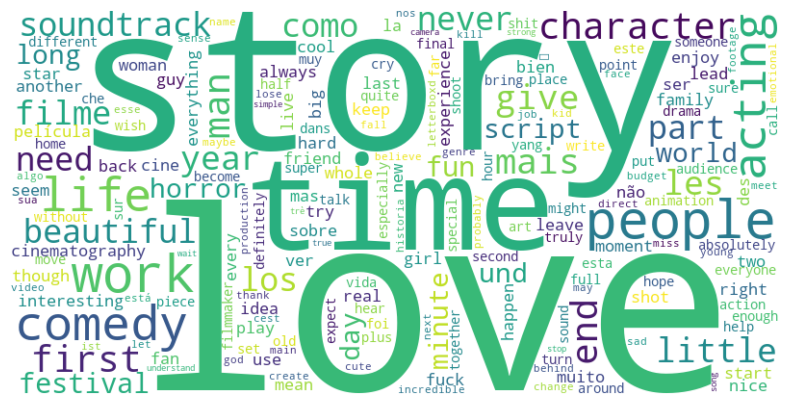

In [14]:
# word cloud generation
all_words = ' '.join([' '.join(review) for review in reviews_df['lemmatized_review_custom']])
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.show()

- "story", "character", "acting", "script", "soundtrack", "cinematography", "cast": sugieren que las personas hablan sobre el trabajo de la gente en la película. Las palabras que fueron añadidas como stopwords, tales como actor, director o film que aparecían con un tamaño grande, también sugerían esto.

- "comedy", "horror", "action", "drama": sugieren que las personas comentan sobre los géneros cinematográficos y cómo la película los cumplió.

- "people", "man", "girl": sugieren que las personas hablan sobre partes específicas de la trama, así como palabras de temporalidad como "start" o "end", pero en este caso sobre los personajes. Es notable cómo la palabra "man" aparece mucho más grande que palabras como "woman" o "girl".

- "beautiful", "interesting", "long", "real", "special", "different", "hard": sugieren que la gente comenta sus impresiones sobre la película, adjetivos calificativos que aunque muestran sentimientos, no son simplemente bueno o malo.


# Part-of-Speech Tagging

Part of Speech (POS) tagging is the process of labeling each word in a text with its corresponding part of speech, such as noun, verb, adjective, adverb, etc. The objective of POS tagging is to provide syntactic information about the words in a sentence, helping to understand the structure and grammatical relationships within the text.

In [15]:
# POS tagging con spaCy (red neuronal del modelo en_core_web_sm)
#
# IMPORTANTE: se etiqueta sobre 'review_text', el texto ORIGINAL, no sobre
# 'normalized_review'. Un etiquetador gramatical se apoya en las mayusculas y
# en la puntuacion para decidir: sin mayusculas no distingue "Apple" (nombre
# propio) de "apple" (sustantivo comun), y sin puntos no sabe donde acaba una
# frase. Etiquetar el texto ya normalizado degrada justo aquello que estos
# modelos hacen bien, y ademas hace injusta la comparacion entre los tres.
df_POS = reviews_df[['review_id', 'review_text']].copy()

def spacy_pos_tagging(doc):
    return [(token.text, token.pos_) for token in doc]

textos_crudos = df_POS['review_text'].tolist()
df_POS['spacy_pos'] = [
    spacy_pos_tagging(doc)
    for doc in nlp_lemma.pipe(textos_crudos, batch_size=1000)
]
df_POS[['review_id', 'review_text', 'spacy_pos']].head()

,review_id,review_text,spacy_pos
0,0,¡QUE PUTA BELLEZA!Definitivamente gracias a es...,"[(¡, NOUN), (QUE, NOUN), (PUTA, VERB), (BELLEZ..."
1,1,Cried way too much over the humble beauty of i...,"[(Cried, VERB), (way, NOUN), (too, ADV), (much..."
2,2,idk if i cried bc of this or my period either ...,"[(idk, INTJ), (if, SCONJ), (i, PRON), (cried, ..."
3,3,Op z’n Nederlands weer slecht geacteerd en gep...,"[(Op, PROPN), (z’n, PUNCT), (Nederlands, PROPN..."
4,4,"""i loved being a witch"" made me cry my eyes out","[("", PUNCT), (i, PRON), (loved, VERB), (being,..."


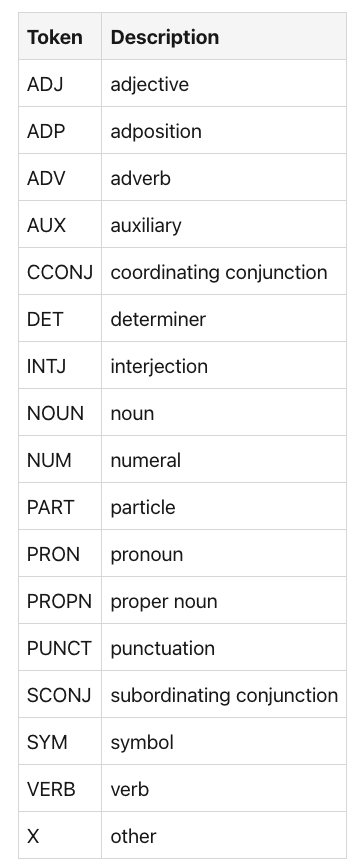

In [16]:
# POS tagging con el perceptron promediado de NLTK, tambien sobre texto original
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def perceptron_pos_tagging(review):
    words = nltk.word_tokenize(review, language='english', preserve_line=True)
    return nltk.pos_tag(words)

from joblib import Parallel, delayed

df_POS['perceptron_pos'] = Parallel(n_jobs=-1)(
    delayed(perceptron_pos_tagging)(review)
    for review in df_POS['review_text']
)
df_POS[['review_id', 'perceptron_pos']].head()

,review_id,perceptron_pos
0,0,"[(¡QUE, JJ), (PUTA, NNP), (BELLEZA, NNP), (!, ..."
1,1,"[(Cried, JJ), (way, NN), (too, RB), (much, RB)..."
2,2,"[(idk, NN), (if, IN), (i, JJ), (cried, VBD), (..."
3,3,"[(Op, NNP), (z, NNP), (’, NNP), (n, JJ), (Nede..."
4,4,"[(``, ``), (i, NN), (loved, VBD), (being, VBG)..."


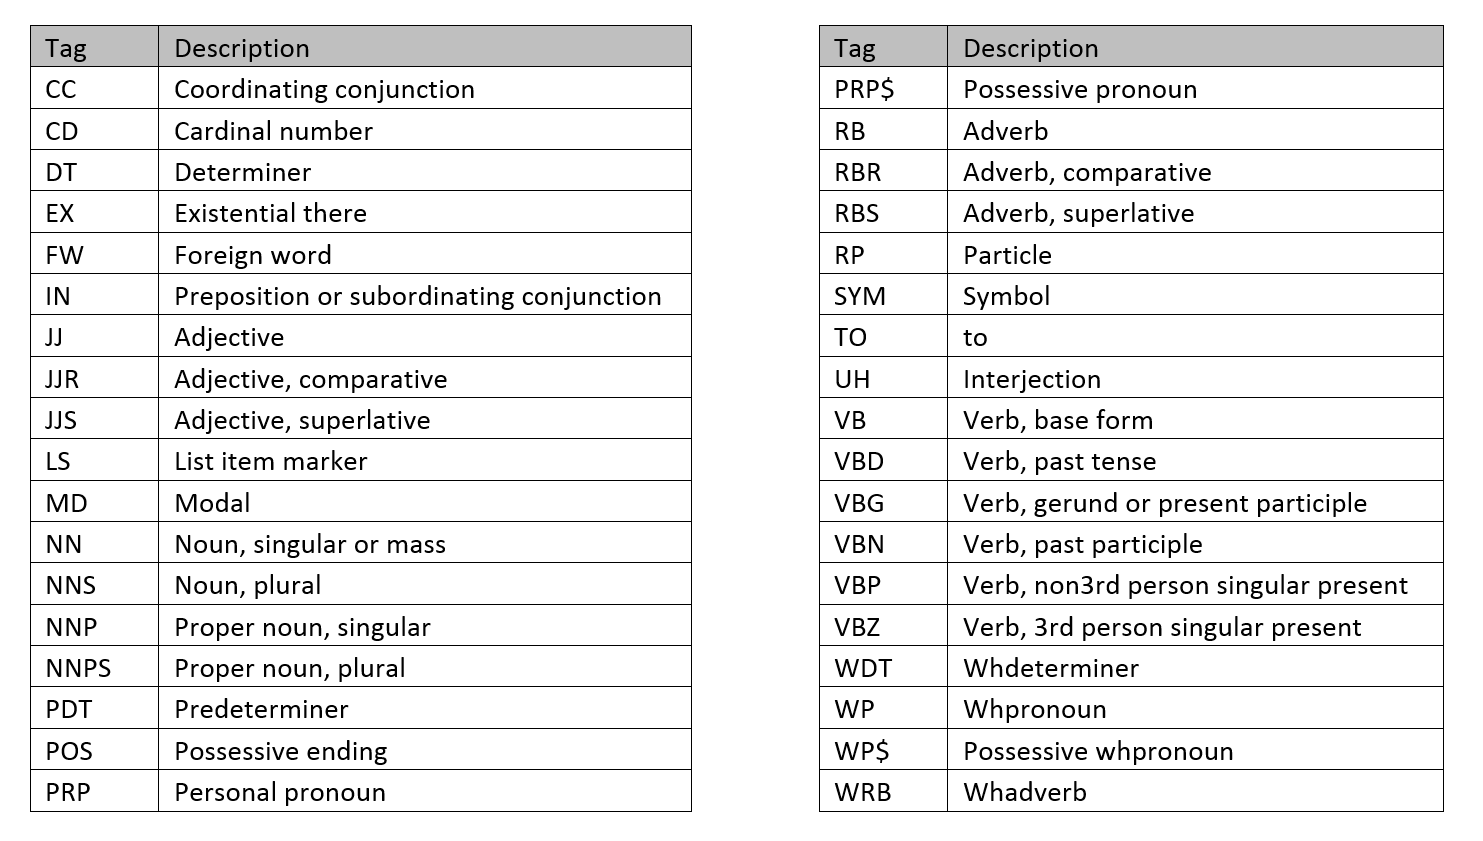

In [17]:
# flair se instala desde requirements.txt (arrastra PyTorch, ~2,5 GB)

POS tagging in Flair leverages contextual string embeddings to assign grammatical labels (like noun, verb, adjective, etc.) to each word in a sentence. Unlike traditional approaches, Flair uses character-level embeddings that adapt based on the context of the word in a given sentence, allowing for more accurate tagging even when words have multiple meanings depending on the context. Flair’s pretrained POS tagging models are built using bi-directional LSTM networks with these embeddings, enabling the model to effectively capture the surrounding context and provide high-quality, state-of-the-art POS tagging out of the box.

In [18]:
from flair.models import SequenceTagger
from flair.data import Sentence

tagger = SequenceTagger.load("pos")


2026-09-03 15:07:45,470 SequenceTagger predicts: Dictionary with 53 tags: <unk>, O, UH, ,, VBD, PRP, VB, PRP$, NN, RB, ., DT, JJ, VBP, VBG, IN, CD, NNS, NNP, WRB, VBZ, WDT, CC, TO, MD, VBN, WP, :, RP, EX, JJR, FW, XX, HYPH, POS, RBR, JJS, PDT, NNPS, RBS, AFX, WP$, -LRB-, -RRB-, ``, '', LS, $, SYM, ADD


In [19]:
# POS tagging con Flair (biLSTM sobre embeddings contextuales de caracteres).
#
# SOBRE UNA MUESTRA, y es una decision consciente: Flair es dos ordenes de
# magnitud mas lento que los otros dos y su salida NO se usa despues —los
# adjetivos se extraen del perceptron de NLTK sobre el corpus completo—. Aqui
# esta para comparar los tres etiquetadores, y para eso una muestra
# representativa basta. Para etiquetar el corpus entero, sube N_MUESTRA_FLAIR.
N_MUESTRA_FLAIR = 500
muestra_flair = df_POS.sample(n=min(N_MUESTRA_FLAIR, len(df_POS)), random_state=42)

def flair_pos_tagging_batch(texts, batch_size=64):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = [Sentence(text) for text in texts[i:i + batch_size]]
        tagger.predict(batch)
        results.extend([
            [(token.text, token.get_labels()[0].value) for token in sentence]
            for sentence in batch
        ])
    return results

flair_pos = flair_pos_tagging_batch(muestra_flair['review_text'].tolist(), batch_size=64)
df_flair = pd.DataFrame({'review_id': muestra_flair['review_id'].values, 'flair_pos': flair_pos})
print(f"Flair ha etiquetado {len(df_flair):,} reseñas de las {len(df_POS):,} del corpus")
df_flair.head()

Flair ha etiquetado 500 reseñas de las 11,968 del corpus


,review_id,flair_pos
0,6260,"[(When, WRB), (death, NN), (is, VBZ), (a, DT),..."
1,1358,"[(Tiene, NNP), (un, UH), (humor, NN), (muy, NN..."
2,10448,"[(a, DT), (tribute, NN), (to, IN), (the, DT), ..."
3,3765,"[(dit, FW), (gekeken, FW), (met, FW), (oma., F..."
4,308,"[(Like, UH), (with, IN), ("", ``), (Schizopolis..."


In [20]:
# Los tres etiquetadores sobre la MISMA reseña, para ver en que se diferencian
ejemplo_id = df_flair['review_id'].iloc[0]
texto = df_POS.loc[df_POS['review_id'] == ejemplo_id, 'review_text'].iloc[0]
print(f"Reseña {ejemplo_id}: {texto[:160]}\n")

comparacion = pd.DataFrame({
    'spaCy': [df_POS.loc[df_POS['review_id'] == ejemplo_id, 'spacy_pos'].iloc[0][:12]],
    'NLTK': [df_POS.loc[df_POS['review_id'] == ejemplo_id, 'perceptron_pos'].iloc[0][:12]],
    'Flair': [df_flair.loc[df_flair['review_id'] == ejemplo_id, 'flair_pos'].iloc[0][:12]],
}).T
for nombre, fila in comparacion.iterrows():
    print(f"--- {nombre} ---")
    print("  " + "  ".join(f"{p}/{t}" for p, t in fila[0]))
    print()

Reseña 6260: When death is a reflection of your life and what you want it can be so beautiful it's very sad alot of people don't get to leave on their own terms

--- spaCy ---
  When/SCONJ  death/NOUN  is/AUX  a/DET  reflection/NOUN  of/ADP  your/PRON  life/NOUN  and/CCONJ  what/PRON  you/PRON  want/VERB

--- NLTK ---
  When/WRB  death/NN  is/VBZ  a/DT  reflection/NN  of/IN  your/PRP$  life/NN  and/CC  what/WP  you/PRP  want/VBP

--- Flair ---
  When/WRB  death/NN  is/VBZ  a/DT  reflection/NN  of/IN  your/PRP$  life/NN  and/CC  what/WP  you/PRP  want/VBP



Los tres usan juegos de etiquetas distintos —spaCy devuelve etiquetas universales (`NOUN`, `VERB`, `ADJ`) y NLTK y Flair el juego de Penn Treebank (`NN`, `VBD`, `JJ`)—, así que no son directamente comparables etiqueta a etiqueta. Lo que sí se ve es cómo cada uno segmenta y resuelve las palabras ambiguas.

Para extraer adjetivos usamos el **perceptrón de NLTK**, porque devuelve Penn Treebank (`JJ`, `JJR`, `JJS`), es el más rápido de los tres y se paraleliza bien con `joblib`.

In [21]:
def extract_adjectives(pos_tags):
    adjectives = [word for word, tag in pos_tags if tag in ['JJ', 'JJR', 'JJS']]
    return " ".join(adjectives)


df_POS['adjectives'] = df_POS['perceptron_pos'].apply(extract_adjectives)
df_POS

,review_id,review_text,spacy_pos,perceptron_pos,adjectives
0,0,¡QUE PUTA BELLEZA!Definitivamente gracias a es...,"[(¡, NOUN), (QUE, NOUN), (PUTA, VERB), (BELLEZ...","[(¡QUE, JJ), (PUTA, NNP), (BELLEZA, NNP), (!, ...",¡QUE esta cuenta una los las todo nunca un un ...
1,1,Cried way too much over the humble beauty of i...,"[(Cried, VERB), (way, NOUN), (too, ADV), (much...","[(Cried, JJ), (way, NN), (too, RB), (much, RB)...",Cried humble survived.Wish
2,2,idk if i cried bc of this or my period either ...,"[(idk, INTJ), (if, SCONJ), (i, PRON), (cried, ...","[(idk, NN), (if, IN), (i, JJ), (cried, VBD), (...",i good
3,3,Op z’n Nederlands weer slecht geacteerd en gep...,"[(Op, PROPN), (z’n, PUNCT), (Nederlands, PROPN...","[(Op, NNP), (z, NNP), (’, NNP), (n, JJ), (Nede...",n wat zonder het een aansnijden ik het onbeken...
4,4,"""i loved being a witch"" made me cry my eyes out","[("", PUNCT), (i, PRON), (loved, VERB), (being,...","[(``, ``), (i, NN), (loved, VBD), (being, VBG)...",
...,...,...,...,...,...
11988,11995,It’s about girlhood it’s about mother-daughter...,"[(It, PRON), (’s, VERB), (about, ADP), (girlho...","[(It, PRP), (’, VBZ), (s, JJ), (about, IN), (g...",s s mother-daughter horny young s s s s s
11989,11996,a lot of setup. no payoff.,"[(a, DET), (lot, NOUN), (of, ADP), (setup, NOU...","[(a, DT), (lot, NN), (of, IN), (setup., JJ), (...",setup.
11990,11997,really enjoyed lots and refreshing to watch so...,"[(really, ADV), (enjoyed, VERB), (lots, NOUN),...","[(really, RB), (enjoyed, VBN), (lots, NNS), (a...",
11991,11998,"Now, I'm a sucker for a good heist/caper movie...","[(Now, ADV), (,, PUNCT), (I, PRON), ('m, AUX),...","[(Now, RB), (,, ,), (I, PRP), ('m, VBP), (a, D...",good mite own


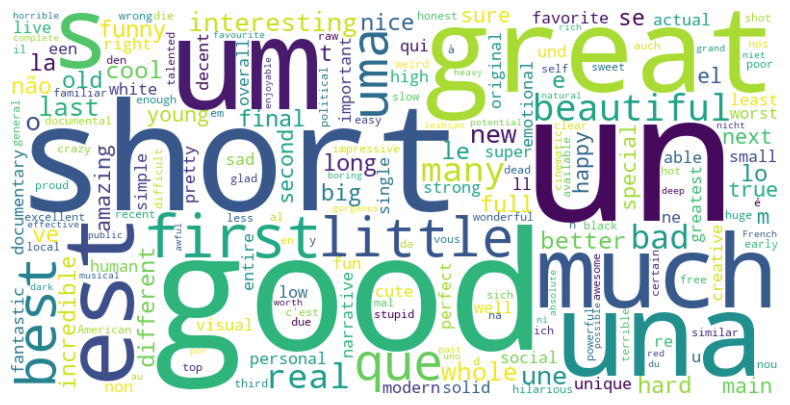

In [22]:
adjectives_text = " ".join(df_POS['adjectives'])
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(adjectives_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Aunque muchos adjetivos que describían sentimientos y opacaban las palabras que buscábamos para el modelado de tópicos, aquí podemos ver palabras como "short", "good", "great", "little", "interesting", "beautiful", "big".

In [23]:
from collections import Counter
df_POS['adjectives_list'] = df_POS['adjectives'].apply(lambda x: x.split())
# Combine adjectives in one list
all_adjectives = sum(df_POS['adjectives_list'].tolist(), [])
#all_adjectives = [adj for adj in all_adjectives if adj.lower() not in ['i', 'other', 'screen']]  # Filter out "i", "other", and "screen"
adjective_counts = Counter(all_adjectives)
most_common_adjectives = adjective_counts.most_common(10)
most_common_adjectives

[('un', 653),
 ('good', 502),
 ('short', 446),
 ('’', 381),
 ('um', 329),
 ('una', 317),
 ('great', 305),
 ('more', 296),
 ('s', 287),
 ('i', 278)]

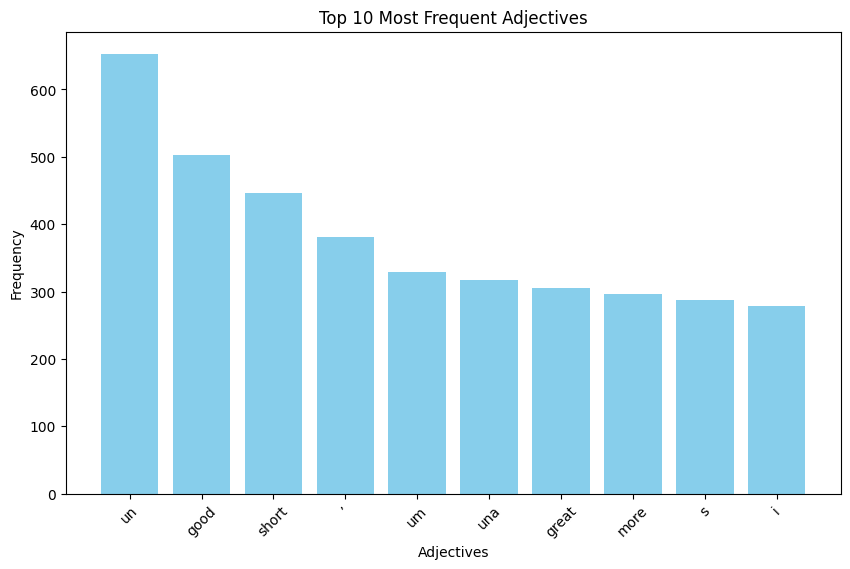

In [24]:
# Separate adjectives and frequencies
adjectives, counts = zip(*most_common_adjectives)

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(adjectives, counts, color='skyblue')
plt.xlabel('Adjectives')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Adjectives')
plt.xticks(rotation=45)
plt.show()

# N-grams Analysis

N-gram analysis with TF-IDF helps capture meaningful word combinations that provide context, such as phrases or expressions that are more informative than individual words. By weighting n-grams based on their relevance across documents, TF-IDF helps reduce the impact of commonly used terms that might not be informative and highlights the n-grams that are more significant in specific contexts.

## Unigrams

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

dft = [str(x) for x in reviews_df['lemmatized_review_custom'] if str(x) != 'nan']  # Convert each non-NaN entry in the 'lemmatized_review_custom' column to a string and store it in a list.
tfIdfVectorizer = TfidfVectorizer(use_idf=True)  # Initialize the TF-IDF vectorizer, enabling the use of the Inverse Document Frequency (IDF) weighting.
tfIdf = tfIdfVectorizer.fit_transform(dft)  # Fit the vectorizer to the data and transform the text into a sparse matrix of TF-IDF features.
names = tfIdfVectorizer.get_feature_names_out()  # Retrieve the feature names (i.e., the words) from the TF-IDF vectorizer.
freqs = tfIdf.sum(axis=0).A1  # Sum the TF-IDF scores for each word across all documents, resulting in the total TF-IDF score for each word.
result = dict(zip(names, freqs))  # Combine the feature names (words) and their corresponding TF-IDF scores into a dictionary.
print(result)

{'aaa': np.float64(0.341...), 'aaaaa': np.float64(0.519...), ... }

[Salida recortada al publicar: el diccionario completo son 2,288,196 caracteres en una sola linea y GitHub no llegaba a renderizar el notebook.
 El codigo es el mismo y al ejecutarlo se imprime entero.
 Los 30 terminos con mayor TF-IDF estan en el grafico de la celda siguiente, que es lo que esta salida servia para calcular.]


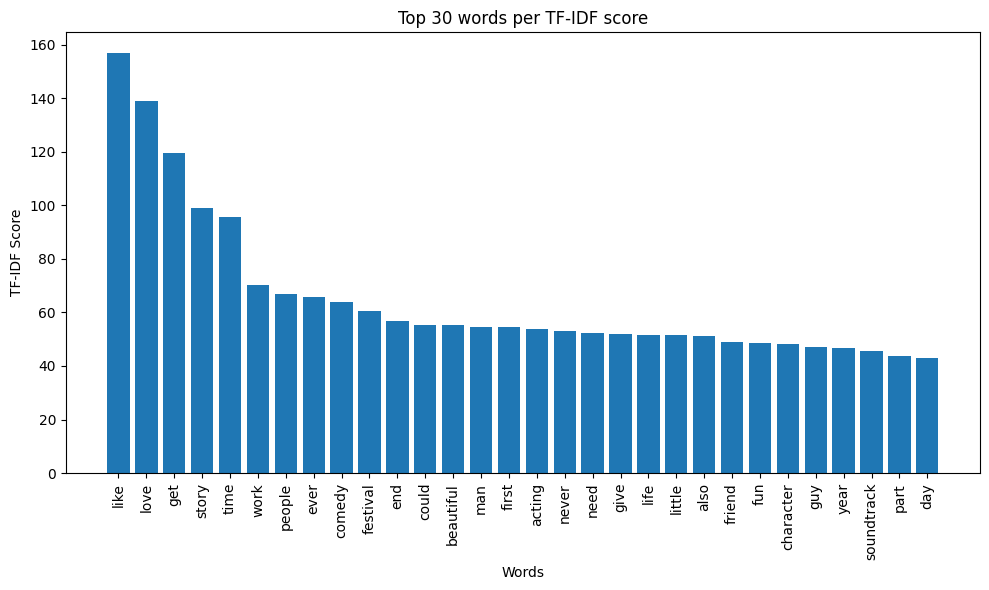

In [26]:
from operator import itemgetter

results_sorted = sorted(result.items(), key=itemgetter(1), reverse=True)  # Sort the dictionary 'result' (which contains words and their TF-IDF scores) by the TF-IDF scores in descending order.
top_words = results_sorted[:30]  # Select the top 30 words with the highest TF-IDF scores.
words, frequencies = zip(*top_words)  # Unpack the top words and their corresponding frequencies into two separate lists: 'words' and 'frequencies'.

plt.figure(figsize=(10, 6))
plt.bar(words, frequencies)
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.title('Top 30 words per TF-IDF score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



Aunque hemos eliminado muchas stopwords que contenían sentimientos, aparecen palabras como "like" que también puede usarse para indicar semejanza, "love" que puede indicar un gran número de reviews provenientes de películas de temántica romántica o cosas que la gente literalmente amó de las películas y documentales. También se ve que se comenta la historia más que los personajes o la actuación, que se menciona mucho más a hombres que a mujeres, apaerce la palabra fuck, se identifican los géneros de comedia y terror

## Bigrams

In [27]:
tfIdfVectorizer_bi = TfidfVectorizer(use_idf = True, ngram_range = (2,2))
tfIdf_bi = tfIdfVectorizer_bi.fit_transform(dft)
names_bi = tfIdfVectorizer_bi.get_feature_names_out()
freqs_bi = tfIdf_bi.sum(axis=0).A1
result_bi = dict(zip(names_bi, freqs_bi))

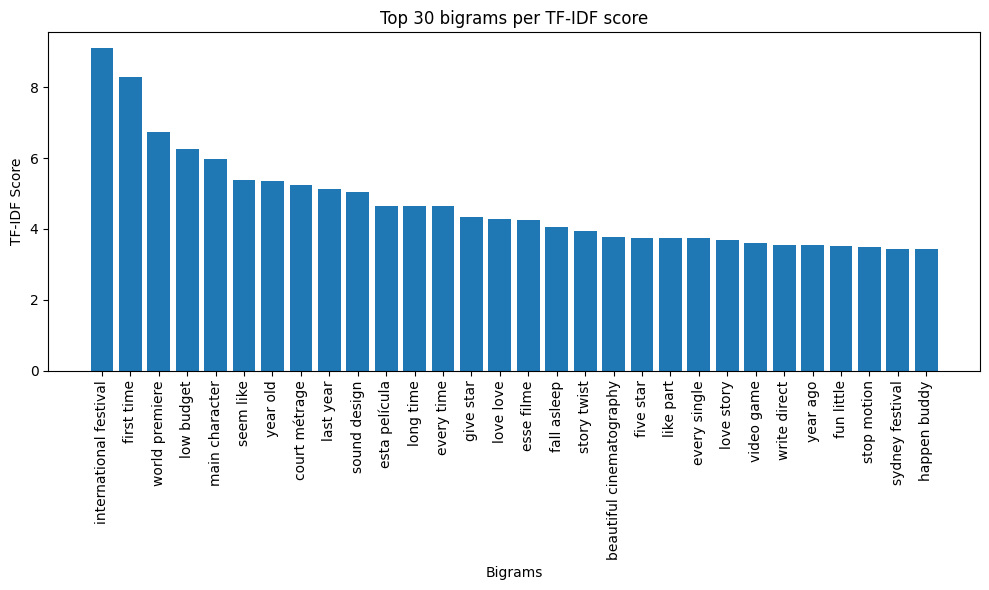

In [28]:
results_sorted_bi = sorted(result_bi.items(), key=itemgetter(1), reverse=True)
top_bi_words = results_sorted_bi[:30]
words_bi, frequencies_bi = zip(*top_bi_words)

plt.figure(figsize=(10, 6))
plt.bar(words_bi, frequencies_bi)
plt.xlabel('Bigrams')
plt.ylabel('TF-IDF Score')
plt.title('Top 30 bigrams per TF-IDF score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Podemos ver "year old" que puede indicar gente comentando la edad de una película o la edad que tenían cuando la vieron por primera vez o algo por le estilo. Que se habla mucho del protagonista, "main character. También que la gente comenta "every time" o "first time" hablando de si vieron la película por primera vez o si hay algo que se repite cada vez que vuelven a ver la película o algo del mismo actor/actriz o director/a. Se habla también de características de las películas como "low budget". "sound design", "english version". Y también gente comentando donde la vio "world premiere", "international festival".

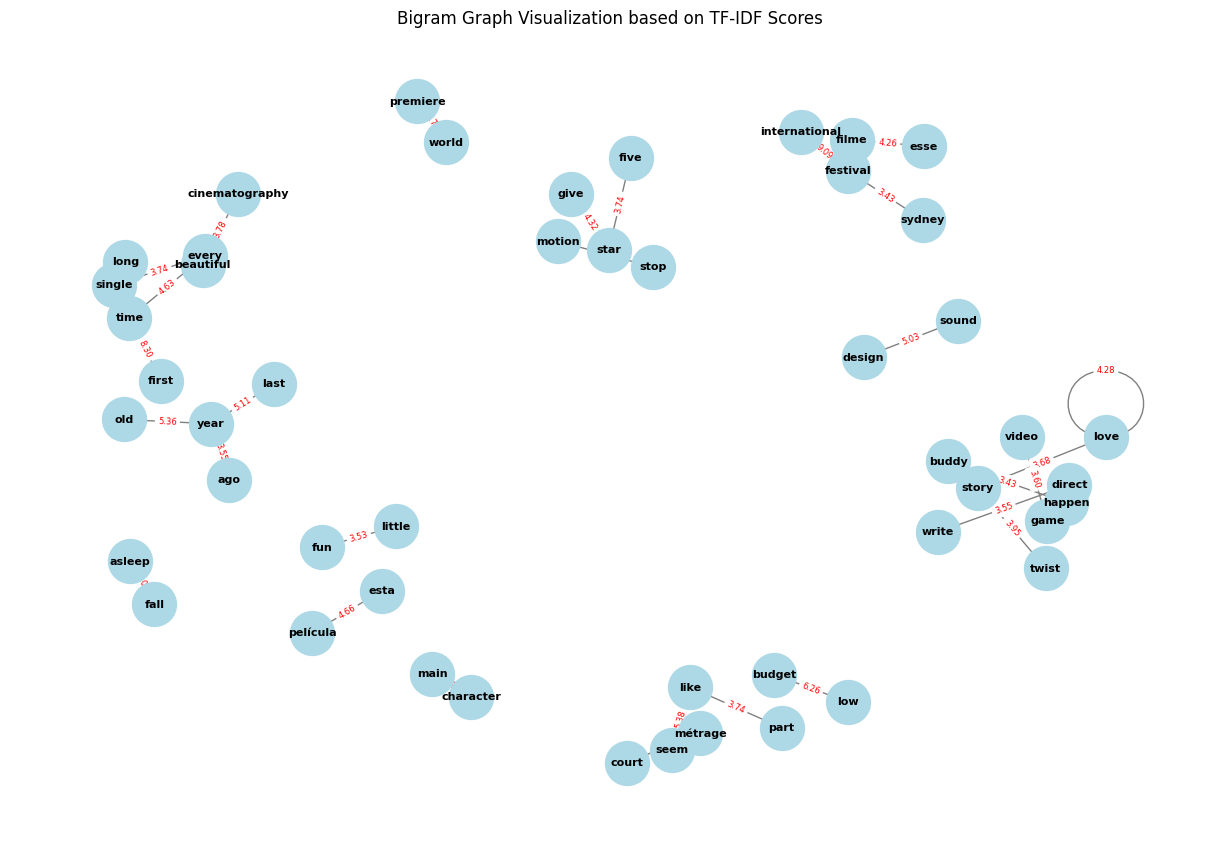

In [29]:
import networkx as nx
# Create a graph using NetworkX
G = nx.Graph()

# Add edges (bigrams) to the graph
for bigram, score in top_bi_words:
    word1, word2 = bigram.split()  # Split the bigram into two words
    G.add_edge(word1, word2, weight=score)  # Add the bigram as an edge with weight as the TF-IDF score

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.6, seed=42)  # 'spring_layout' arranges the graph in a visually pleasing way
# Draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=8, font_weight='bold', edge_color='gray')
# Draw edge labels to represent the TF-IDF scores
edge_labels = {(word1, word2): f'{score:.2f}' for word1, word2, score in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=6)
plt.title('Bigram Graph Visualization based on TF-IDF Scores')
plt.show()

"International festival"
"English version"
"Low Budget"
"Fall love" o "Love story"
"True story"

Empiezan a indicar posibles tópicos como el génro de la película , la experiencia del usuario, opiniones subjetivas, dónde y como vio la película.

Además de algunas palabras de otros idiomas que han conseguido colarse pero que no serán representativas al final del día.

## Trigrams


In [30]:
tfIdfVectorizer_tri = TfidfVectorizer(use_idf = True, ngram_range = (3,3))
tfIdf_tri = tfIdfVectorizer_tri.fit_transform(dft)
names_tri = tfIdfVectorizer_tri.get_feature_names_out()
freqs_tri = tfIdf_tri.sum(axis=0).A1
result_tri = dict(zip(names_tri, freqs_tri))

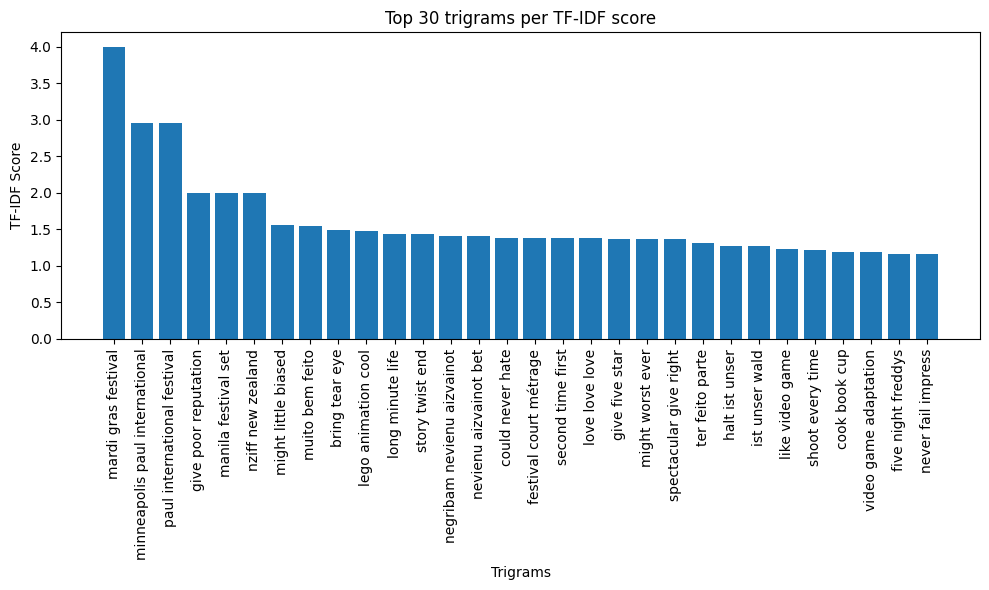

In [31]:
results_sorted_tri = sorted(result_tri.items(), key=itemgetter(1), reverse=True)
top_tri_words = results_sorted_tri[:30]
words_tri, frequencies_tri = zip(*top_tri_words)

plt.figure(figsize=(10, 6))
plt.bar(words_tri, frequencies_tri)
plt.xlabel('Trigrams')
plt.ylabel('TF-IDF Score')
plt.title('Top 30 trigrams per TF-IDF score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- Es interesante que se puede ver el uso de memes en los trigramas más usados. Construcciones que se repiten como "close enough welcome..." "enough welcome back...", "weird happen twice" (if I had a ... for every... but it's weird it happened twice), god forbid woman have hobbies, fuck ass bob, babe wake up new... just dropped.

- También muchas menciones a anime, gente logeando ciertas listas.

. Otra cosa que se ve es de neuvo gente comentando el festival donde vio la película, o su opiniñon "breath fresh air".

- También características de la película como "base true story"

- Y curiosamente uno de los trigramas más usados es "dead poet society"

# Additional Analysis

Analyzing the word length of reviews provides valuable insights into the depth, quality, and engagement of customer feedback. Longer reviews tend to offer more detailed and comprehensive information about a user’s experience, while shorter reviews may be more concise and to the point.

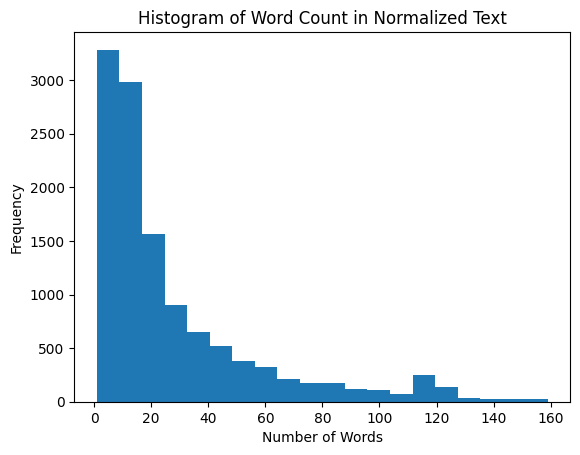

In [32]:
reviews_df['word_count'] = reviews_df['normalized_review'].apply(lambda x: len(str(x).split()))

# Generate the histogram
plt.hist(reviews_df['word_count'], bins=20)  # Adjust the number of bins as needed
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram of Word Count in Normalized Text')
plt.show()


- La distribución tiene una fuerte asimetría a la derecha, indicando que la mayoría son cortas, con la mayoría siendo de menos de 50 palaras.

- También hay un repunte de reviews entre 110 y 120 palabras, de gente que se explaya más que dar una breve opinión. Críticos profesionales que inclluyen un link o aficionados al cine más serios que quieren emularlos.

- Aún así, la mayoría son cortas y concretas.

# Lexical Diversity Analysis

Lexical Diversity Analysis, using the Type-Token Ratio (TTR), measures the variety of vocabulary used in a text, which can provide insights into the richness and complexity of the language. A higher TTR indicates greater lexical diversity, meaning that a larger proportion of unique words are being used relative to the total word count. This is valuable for understanding the level of detail or expressiveness in reviews. In addition, it is also important for evaluating the quality of text preprocessing. A high TTR after preprocessing can indicate that the steps taken—such as stop-word removal, lemmatization, and tokenization—have successfully reduced noise and redundancy while preserving meaningful content. Conversely, a low TTR may suggest that there are still repetitive or irrelevant words, like unfiltered stop words or improper lemmatization, affecting the diversity of the text.

In [33]:
# Diversidad lexica (Type-Token Ratio): palabras distintas / palabras totales
def calculate_ttr(tokens):
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

# LAS DOS COLUMNAS TIENEN QUE SER LISTAS DE PALABRAS.
# En la version anterior, TTR_raw se calculaba sobre 'normalized_review', que
# es un STRING: set() sobre un string devuelve sus CARACTERES, asi que aquello
# media letras distintas / letras totales. De ahi que saliera entre 0,0 y 0,3
# —el alfabeto no crece pero el texto si— frente a 0,8-1,0 del otro. No eran
# dos medidas de lo mismo, y por tanto no se podian comparar.
reviews_df['TTR_pre'] = reviews_df['lemmatized_review_custom'].apply(calculate_ttr)
reviews_df['TTR_raw'] = reviews_df['normalized_review'].apply(lambda t: calculate_ttr(str(t).split()))

print("Type-Token Ratio, ahora las dos sobre palabras:")
print(reviews_df[['TTR_raw', 'TTR_pre']].describe().round(3).to_string())
print(f"\nMedia antes del preprocesado : {reviews_df['TTR_raw'].mean():.3f}")
print(f"Media despues                : {reviews_df['TTR_pre'].mean():.3f}")
print(f"Diferencia                   : {reviews_df['TTR_pre'].mean() - reviews_df['TTR_raw'].mean():+.3f}")
print(f"\nPalabras por reseña: {reviews_df['normalized_review'].str.split().str.len().mean():.1f} antes, "
      f"{reviews_df['lemmatized_review_custom'].str.len().mean():.1f} despues")

Type-Token Ratio, ahora las dos sobre palabras:
         TTR_raw    TTR_pre
count  11968.000  11968.000
mean       0.918      0.965
std        0.098      0.093
min        0.054      0.000
25%        0.857      0.960
50%        0.949      1.000
75%        1.000      1.000
max        1.000      1.000

Media antes del preprocesado : 0.918
Media despues                : 0.965
Diferencia                   : +0.047

Palabras por reseña: 27.7 antes, 14.5 despues


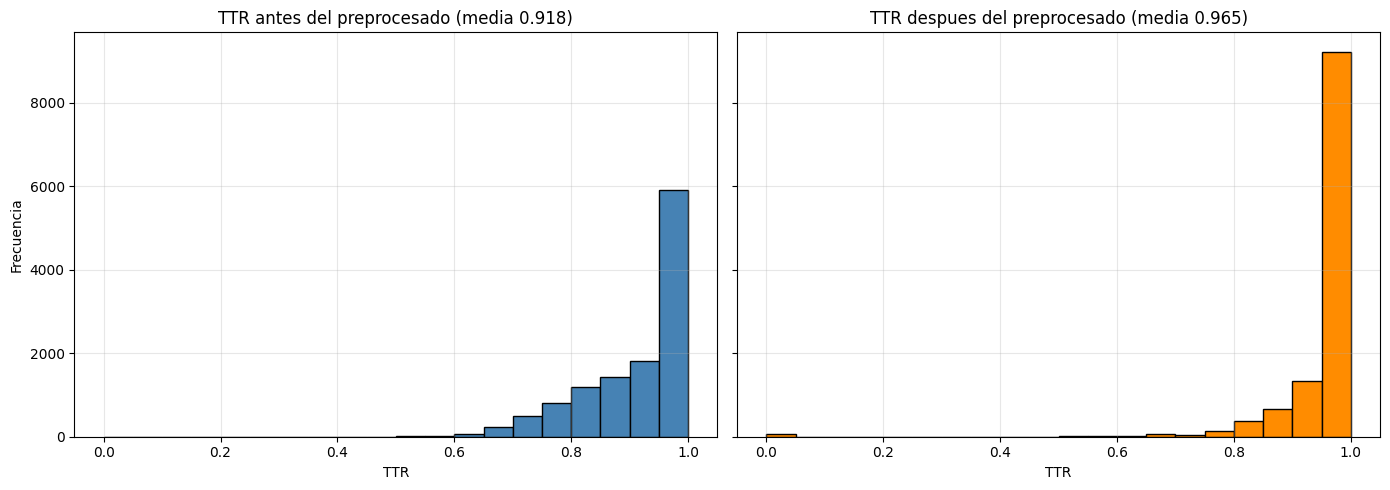

In [34]:
# Los dos histogramas con los MISMOS ejes, que es la unica forma de compararlos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
ax1.hist(reviews_df['TTR_raw'], bins=20, range=(0, 1), edgecolor='black', color='steelblue')
ax1.set_title(f"TTR antes del preprocesado (media {reviews_df['TTR_raw'].mean():.3f})")
ax1.set_xlabel('TTR'); ax1.set_ylabel('Frecuencia'); ax1.grid(True, alpha=.3)
ax2.hist(reviews_df['TTR_pre'], bins=20, range=(0, 1), edgecolor='black', color='darkorange')
ax2.set_title(f"TTR despues del preprocesado (media {reviews_df['TTR_pre'].mean():.3f})")
ax2.set_xlabel('TTR'); ax2.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

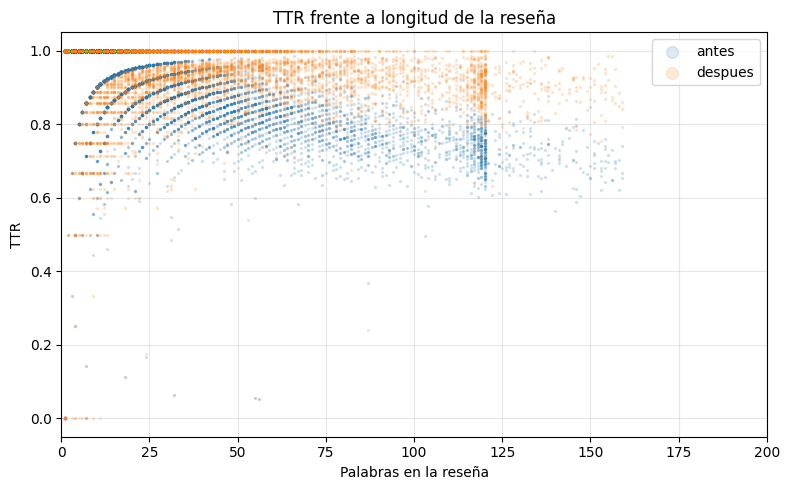

In [35]:
# Relacion entre longitud de la reseña y TTR: el TTR baja con la longitud por
# pura aritmetica, asi que comparar medias sin mirar esto puede engañar.
fig, ax = plt.subplots(figsize=(8, 5))
largo = reviews_df['normalized_review'].str.split().str.len()
ax.scatter(largo, reviews_df['TTR_raw'], s=2, alpha=.15, label='antes')
ax.scatter(largo, reviews_df['TTR_pre'], s=2, alpha=.15, label='despues')
ax.set_xlim(0, 200); ax.set_xlabel('Palabras en la reseña'); ax.set_ylabel('TTR')
ax.set_title('TTR frente a longitud de la reseña'); ax.legend(markerscale=6)
ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

**Diversidad léxica (TTR): qué dicen los datos, y qué no.**

| | media | mediana | palabras/reseña |
| --- | --- | --- | --- |
| Antes del preprocesado | **0,918** | 0,949 | 27,7 |
| Después | **0,965** | 1,000 | 14,5 |
| Diferencia | **+0,047** | | |

El preprocesamiento **sube el TTR, pero muy poco**: 4,7 centésimas. Y hay que decir por qué esa cifra no permite concluir gran cosa.

**El TTR está saturado en este corpus.** Las reseñas de Letterboxd son cortísimas —27,7 palabras de media antes de limpiar, 14,5 después—, y en textos tan breves casi ninguna palabra se repite. De hecho la mediana después del preprocesado es **1,000**: en la mitad de las reseñas *todas* las palabras son distintas. Cuando una métrica toca su techo en la mitad de los casos, deja de discriminar.

**Y el TTR depende de la longitud.** Baja cuando el texto crece, por pura aritmética: el vocabulario de una persona es finito y las palabras totales no. Así que comparar un corpus de 27,7 palabras por documento con uno de 14,5 **no es una comparación limpia**: parte de esa subida de +0,047 se explica solo porque los textos son ahora más cortos, no porque sean más ricos. El gráfico de TTR frente a longitud lo enseña.

**Conclusión honesta:** con estos datos, el TTR no sirve para afirmar que el preprocesamiento haya mejorado la calidad del corpus. Sube un poco, pero la métrica está saturada y confundida con la longitud. Lo que sí sabemos del preprocesamiento es lo que se ve directamente: pasa de 27,7 a 14,5 palabras por reseña quitando stopwords y unificando formas.

---

*Nota sobre la versión anterior de este análisis.* Antes se comparaban dos cosas distintas: el TTR posterior se calculaba sobre una **lista de palabras** y el anterior sobre un **string**, y `set()` sobre un string devuelve sus **caracteres**. Aquello medía letras distintas / letras totales y por eso salía entre 0,0 y 0,3, frente al 0,8-1,0 del otro. De ahí la conclusión de que el preprocesamiento "aumentaba significativamente la diversidad léxica": era el artefacto de comparar palabras con letras. Corregido el cálculo, la diferencia real es de +0,047.

In [36]:
# Unir el POS tagging con su reseña POR IDENTIFICADOR.
# La version anterior unia por 'normalized_review', que es texto libre: dos
# reseñas distintas pueden normalizarse al mismo texto ("Great!" y "great"),
# y entonces el merge multiplica filas. Con el id no puede pasar.
antes = len(reviews_df)
reviews_df = reviews_df.merge(
    df_POS[['review_id', 'spacy_pos', 'perceptron_pos']], on='review_id', how='left'
)
reviews_df = reviews_df.merge(df_flair, on='review_id', how='left')
assert len(reviews_df) == antes, "el merge ha cambiado el numero de filas"
print(f"Merge por review_id: {antes:,} filas antes, {len(reviews_df):,} despues (sin duplicar)")
print(f"Reseñas con etiquetado de Flair: {reviews_df['flair_pos'].notna().sum():,} (la muestra)")

Merge por review_id: 11,968 filas antes, 11,968 despues (sin duplicar)
Reseñas con etiquetado de Flair: 500 (la muestra)


# Detección de idioma

El corpus es multilingüe: son reseñas de Letterboxd de todo el mundo. Las stopwords multilingües que quitamos antes son una lista escrita a mano de 28 palabras, y eso no cubre ni de lejos el francés, el alemán, el portugués, el español, el italiano, el indonesio, el persa, el árabe, el polaco o el tamil que hay en el corpus.

Detectamos el idioma de cada reseña para poder, más adelante, **comparar el modelado sobre el corpus completo frente al modelado solo sobre inglés**. No descartamos nada aquí: se añade una columna y se guardan los dos corpus.

**Por qué `langdetect`.** Es una implementación en Python puro del detector de Google, sin dependencias pesadas ni descargas de modelo, y con `DetectorFactory.seed` fijo es determinista. Con reseñas cortas —la mediana de este corpus está en unas 16 palabras— ningún detector es fiable, así que las reseñas muy cortas se marcan aparte en vez de asignarles un idioma a la fuerza.

In [37]:
from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 0     # langdetect es probabilistico: sin esto no repite

MIN_CARACTERES = 20   # por debajo de esto la deteccion es una moneda al aire

def detectar_idioma(texto):
    t = str(texto).strip()
    if len(t) < MIN_CARACTERES:
        return 'corta'
    try:
        return detect(t)
    except LangDetectException:
        return 'desconocido'

# Se detecta sobre el texto ORIGINAL: la normalizacion quita acentos indirectos,
# puntuacion y mayusculas, que son señales utiles para el detector.
reviews_df['lang'] = reviews_df['review_text'].apply(detectar_idioma)

reparto = reviews_df['lang'].value_counts()
print(f"Idiomas detectados: {reviews_df['lang'].nunique()}")
print(f"\nTop 15 por numero de reseñas:")
for lang, n in reparto.head(15).items():
    print(f"   {lang:<12} {n:>7,}  ({n/len(reviews_df)*100:>5.1f}%)")
print(f"\nIngles: {reparto.get('en', 0):,} reseñas "
      f"({reparto.get('en', 0)/len(reviews_df)*100:.1f}% del corpus)")
print(f"Demasiado cortas para detectar: {reparto.get('corta', 0):,} "
      f"({reparto.get('corta', 0)/len(reviews_df)*100:.1f}%)")

Idiomas detectados: 48

Top 15 por numero de reseñas:
   en             7,465  ( 62.4%)
   es               889  (  7.4%)
   fr               763  (  6.4%)
   pt               714  (  6.0%)
   de               246  (  2.1%)
   it               239  (  2.0%)
   id               163  (  1.4%)
   ru               142  (  1.2%)
   tr               124  (  1.0%)
   nl               108  (  0.9%)
   ar               103  (  0.9%)
   th                75  (  0.6%)
   tl                74  (  0.6%)
   pl                60  (  0.5%)
   ca                58  (  0.5%)

Ingles: 7,465 reseñas (62.4% del corpus)
Demasiado cortas para detectar: 0 (0.0%)


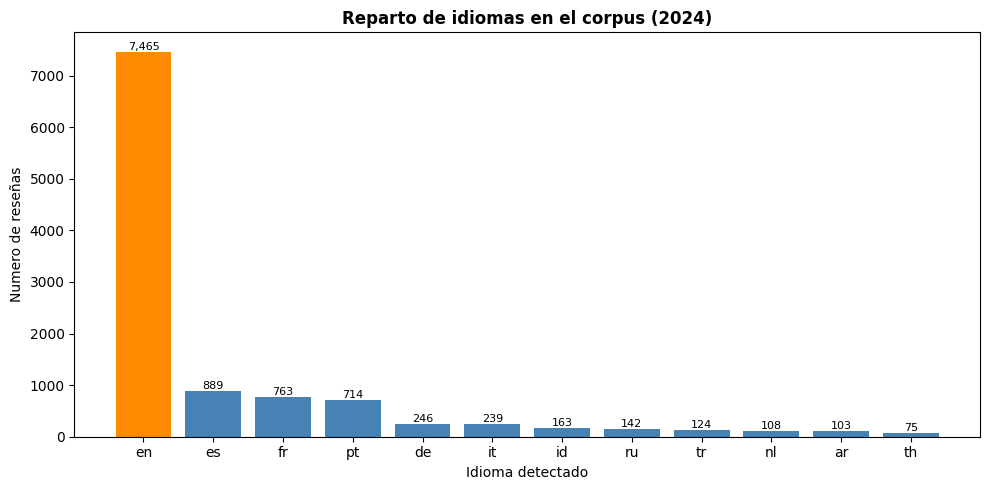

In [38]:
# Grafico del reparto por idioma
top = reviews_df['lang'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['darkorange' if l == 'en' else 'steelblue' for l in top.index]
ax.bar(top.index, top.values, color=colores)
ax.set_xlabel('Idioma detectado'); ax.set_ylabel('Numero de reseñas')
ax.set_title('Reparto de idiomas en el corpus (2024)', fontweight='bold')
for x, v in enumerate(top.values):
    ax.text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [39]:
# Guardar los DOS corpus: el completo y el filtrado a ingles.
# El experimento del notebook 2 compara el modelado sobre uno y sobre otro,
# asi que hacen falta los dos y con el mismo preprocesamiento.
reviews_df.to_parquet('letterboxd_reviews_preprocessed.parquet', index=False)
print(f"Corpus completo   : {len(reviews_df):,} reseñas, "
      f"{reviews_df['title'].nunique():,} peliculas")

reviews_en = reviews_df[reviews_df['lang'] == 'en'].reset_index(drop=True)
reviews_en.to_parquet('letterboxd_reviews_preprocessed_en.parquet', index=False)
print(f"Corpus solo ingles: {len(reviews_en):,} reseñas, "
      f"{reviews_en['title'].nunique():,} peliculas "
      f"({len(reviews_en)/len(reviews_df)*100:.1f}% del total)")
print("\nNinguno de los dos .parquet se sube al repositorio: los regenera este notebook.")

Corpus completo   : 11,968 reseñas, 8,470 peliculas


Corpus solo ingles: 7,465 reseñas, 5,555 peliculas (62.4% del total)

Ninguno de los dos .parquet se sube al repositorio: los regenera este notebook.
